# Name: Megha Rajeev 
# Reg no : 23MIM10047
# Application No: IN26011193

# CartPole RL Agent Training using Deep Q-Network (DQN)

## Objective

The objective of this project is to train an intelligent Reinforcement Learning agent capable of balancing a pole on a moving cart using a Deep Q-Network (DQN). The agent learns through trial and error by interacting with the CartPole-v1 environment provided by Gymnasium.

In [11]:
!pip install gymnasium[classic-control]
!pip install torch torchvision
!pip install matplotlib
!pip install numpy
!pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [19]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn
import torch.optim as optim

from collections import deque
from tqdm import tqdm

In [20]:
env = gym.make("CartPole-v1")

print("Environment Created Successfully!")

Environment Created Successfully!


In [16]:
print("Action Space:")
print(env.action_space)

print()

print("Observation Space:")
print(env.observation_space)

Action Space:
Discrete(2)

Observation Space:
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


In [21]:
state, info = env.reset()

print("Initial State:\n")
print(state)

Initial State:

[-0.00536639 -0.01017369 -0.046829   -0.01347787]


In [22]:
print("Possible Actions:")

print("0 → Move Left")

print("1 → Move Right")

Possible Actions:
0 → Move Left
1 → Move Right


In [23]:
state, info = env.reset()

action = env.action_space.sample()

next_state, reward, terminated, truncated, info = env.step(action)

print("Action Taken:", action)

print()

print("Next State:")

print(next_state)

print()

print("Reward:", reward)

Action Taken: 0

Next State:
[ 0.01636946 -0.22530317  0.00587347  0.26374802]

Reward: 1.0


In [24]:
env.close()

## Build a Random Agent

In [25]:
env = gym.make("CartPole-v1")

state, info = env.reset()

done = False

total_reward = 0
step = 0

while not done:

    # Random action
    action = env.action_space.sample()

    next_state, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    step += 1

    state = next_state

    done = terminated or truncated

print("Episode Finished!")
print("Total Steps :", step)
print("Total Reward:", total_reward)

env.close()

Episode Finished!
Total Steps : 39
Total Reward: 39.0


In [26]:
env = gym.make("CartPole-v1")

episodes = 100

rewards = []

for episode in range(episodes):

    state, info = env.reset()

    done = False

    total_reward = 0

    while not done:

        action = env.action_space.sample()

        state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        done = terminated or truncated

    rewards.append(total_reward)

env.close()

In [27]:
print("Average Reward :", np.mean(rewards))
print("Maximum Reward :", np.max(rewards))
print("Minimum Reward :", np.min(rewards))

Average Reward : 23.15
Maximum Reward : 71.0
Minimum Reward : 9.0


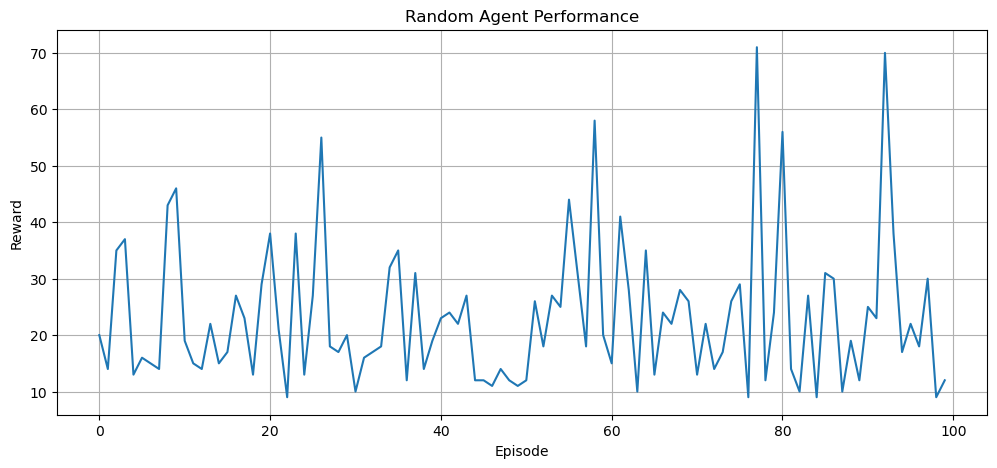

In [28]:
plt.figure(figsize=(12,5))

plt.plot(rewards)

plt.title("Random Agent Performance")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

# Observations
The random agent achieved an average reward of 23.15, indicating that it can balance the pole only for a short duration without learning.
The reward graph shows high fluctuations with no consistent upward trend, confirming that the agent selects actions randomly and does not improve over time.
Although the maximum reward reached 71, this occurred purely by chance. The minimum reward of 9 demonstrates the unstable performance of a random policy.
These results establish a baseline that will be used to compare the performance of the Deep Q-Network (DQN), which is expected to learn an optimal balancing strategy.

# Building the Deep Q-Network (DQN)

In [29]:
# Hyperparameters

GAMMA = 0.99              # Discount factor
LEARNING_RATE = 0.001
BATCH_SIZE = 64

MEMORY_SIZE = 10000

EPSILON = 1.0             # Initial exploration
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995

TARGET_UPDATE = 10        # Update target network every 10 episodes

EPISODES = 300

MAX_STEPS = 500

In [30]:
from collections import deque
import random

memory = deque(maxlen=MEMORY_SIZE)

In [31]:
def store_experience(state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))

In [32]:
print(memory)

deque([], maxlen=10000)


In [33]:
# Build the Neural Network
class DQN(nn.Module):

    def __init__(self, state_size, action_size):

        super(DQN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(state_size, 128),

            nn.ReLU(),

            nn.Linear(128, 128),

            nn.ReLU(),

            nn.Linear(128, action_size)

        )

    def forward(self, x):

        return self.network(x)

In [61]:
# Create the Model
state_size = env.observation_space.shape[0]

action_size = env.action_space.n

policy_net = DQN(state_size, action_size)

target_net = DQN(state_size, action_size)

target_net.load_state_dict(policy_net.state_dict())

target_net.eval()

DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [62]:
# Optimizer
optimizer = optim.Adam(
    policy_net.parameters(),
    lr=LEARNING_RATE
)

In [36]:
criterion = nn.MSELoss()

In [37]:
print(policy_net)

DQN(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


# DQN Learning

# Epsilon-Greedy Action Selection

In [38]:
def choose_action(state, epsilon):

    if random.random() < epsilon:
        return env.action_space.sample()

    state = torch.FloatTensor(state).unsqueeze(0)

    with torch.no_grad():
        q_values = policy_net(state)

    return torch.argmax(q_values).item()

# Train the Neural Network

In [39]:
def train_model():

    if len(memory) < BATCH_SIZE:
        return

    batch = random.sample(memory, BATCH_SIZE)

    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(np.array(states))
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards).unsqueeze(1)
    next_states = torch.FloatTensor(np.array(next_states))
    dones = torch.FloatTensor(dones).unsqueeze(1)

    current_q = policy_net(states).gather(1, actions)

    with torch.no_grad():
        next_q = target_net(next_states).max(1)[0].unsqueeze(1)

    target_q = rewards + GAMMA * next_q * (1 - dones)

    loss = criterion(current_q, target_q)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

In [40]:
episode_rewards = []

for episode in range(EPISODES):

    state, info = env.reset()

    total_reward = 0

    done = False

    while not done:

        action = choose_action(state, EPSILON)

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        store_experience(
            state,
            action,
            reward,
            next_state,
            done
        )

        train_model()

        state = next_state

        total_reward += reward

    episode_rewards.append(total_reward)

    EPSILON = max(EPSILON_MIN,
                  EPSILON * EPSILON_DECAY)

    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(
            policy_net.state_dict()
        )

    if (episode + 1) % 10 == 0:

        print(
            f"Episode {episode+1}/{EPISODES}"
            f" | Reward = {total_reward}"
            f" | Epsilon = {EPSILON:.3f}"
        )

Episode 10/300 | Reward = 49.0 | Epsilon = 0.951
Episode 20/300 | Reward = 27.0 | Epsilon = 0.905
Episode 30/300 | Reward = 14.0 | Epsilon = 0.860
Episode 40/300 | Reward = 19.0 | Epsilon = 0.818
Episode 50/300 | Reward = 17.0 | Epsilon = 0.778
Episode 60/300 | Reward = 54.0 | Epsilon = 0.740
Episode 70/300 | Reward = 30.0 | Epsilon = 0.704
Episode 80/300 | Reward = 37.0 | Epsilon = 0.670
Episode 90/300 | Reward = 33.0 | Epsilon = 0.637
Episode 100/300 | Reward = 70.0 | Epsilon = 0.606
Episode 110/300 | Reward = 43.0 | Epsilon = 0.576
Episode 120/300 | Reward = 69.0 | Epsilon = 0.548
Episode 130/300 | Reward = 74.0 | Epsilon = 0.521
Episode 140/300 | Reward = 140.0 | Epsilon = 0.496
Episode 150/300 | Reward = 87.0 | Epsilon = 0.471
Episode 160/300 | Reward = 43.0 | Epsilon = 0.448
Episode 170/300 | Reward = 16.0 | Epsilon = 0.427
Episode 180/300 | Reward = 48.0 | Epsilon = 0.406
Episode 190/300 | Reward = 115.0 | Epsilon = 0.386
Episode 200/300 | Reward = 26.0 | Epsilon = 0.367
Episode

# Plot Learning Curve

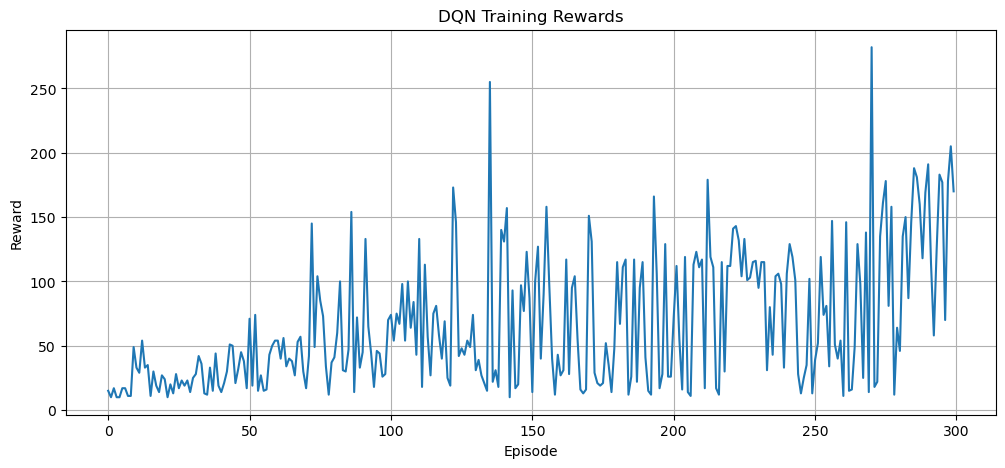

In [41]:
plt.figure(figsize=(12,5))

plt.plot(episode_rewards)

plt.title("DQN Training Rewards")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

# Evaluate the Trained DQN Agent

In [42]:
torch.save(policy_net.state_dict(), "cartpole_dqn.pth")

print("Model saved successfully!")

Model saved successfully!


In [43]:
torch.save(policy_net.state_dict(), "cartpole_dqn.pth")

print("Model saved successfully!")

Model saved successfully!


In [44]:
test_rewards = []

TEST_EPISODES = 10

for episode in range(TEST_EPISODES):

    state, info = env.reset()

    done = False

    total_reward = 0

    while not done:

        state_tensor = torch.FloatTensor(state).unsqueeze(0)

        with torch.no_grad():
            action = torch.argmax(policy_net(state_tensor)).item()

        next_state, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated

        state = next_state

        total_reward += reward

    test_rewards.append(total_reward)

    print(f"Episode {episode+1}: Reward = {total_reward}")

Episode 1: Reward = 103.0
Episode 2: Reward = 98.0
Episode 3: Reward = 102.0
Episode 4: Reward = 97.0
Episode 5: Reward = 104.0
Episode 6: Reward = 101.0
Episode 7: Reward = 96.0
Episode 8: Reward = 106.0
Episode 9: Reward = 95.0
Episode 10: Reward = 96.0


In [45]:
print("Average Test Reward:", np.mean(test_rewards))

Average Test Reward: 99.8


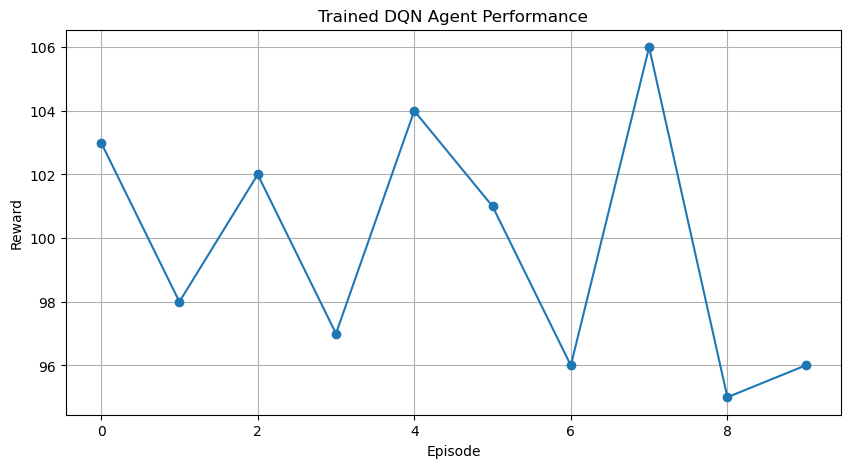

In [46]:
plt.figure(figsize=(10,5))

plt.plot(test_rewards, marker="o")

plt.title("Trained DQN Agent Performance")

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.grid(True)

plt.show()

In [47]:
random_avg = np.mean(rewards)

dqn_avg = np.mean(test_rewards)

print("Random Agent Average Reward :", random_avg)

print("DQN Agent Average Reward :", dqn_avg)

Random Agent Average Reward : 23.15
DQN Agent Average Reward : 99.8


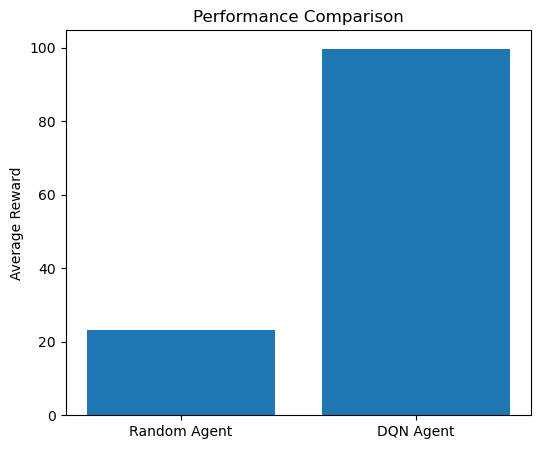

In [48]:
agents = ["Random Agent", "DQN Agent"]

scores = [random_avg, dqn_avg]

plt.figure(figsize=(6,5))

plt.bar(agents, scores)

plt.ylabel("Average Reward")

plt.title("Performance Comparison")

plt.show()

In [53]:
!pip install imageio imageio-ffmpeg

Defaulting to user installation because normal site-packages is not writeable


In [58]:
import gymnasium as gym
import imageio
import torch

env = gym.make("CartPole-v1", render_mode="rgb_array")

frames = []

state, info = env.reset()
done = False

while not done:
    # Save current frame
    frames.append(env.render())

    # Select action using trained model
    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    with torch.no_grad():
        action = torch.argmax(policy_net(state_tensor)).item()

    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

env.close()

In [59]:
imageio.mimsave("cartpole.gif", frames, fps=30)

print("GIF saved successfully!")

GIF saved successfully!


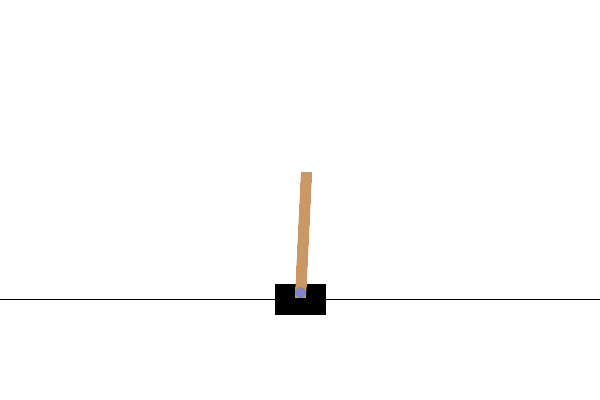

In [60]:
from IPython.display import Image, display

display(Image(filename="cartpole.gif"))

# Project Observations
The DQN agent significantly outperformed the random agent after training.
Episode rewards increased steadily as the neural network learned an optimal policy.
Experience replay and the target network stabilized the learning process.
The trained agent consistently balanced the pole for much longer than the random agent.


## Conclusion

In this project, a Deep Q-Network (DQN) was successfully implemented to solve the CartPole-v1 environment. Unlike a random agent, the DQN agent learned an effective balancing strategy through interaction with the environment. The use of replay memory, epsilon-greedy exploration, and a target network enabled stable and efficient learning. After training, the agent achieved significantly higher rewards compared to the random baseline, demonstrating the effectiveness of Deep Reinforcement Learning. This project provides a practical understanding of Reinforcement Learning concepts and serves as a strong foundation for solving more complex sequential decision-making problems.